# 14 — Selección operativa: D2 como alerta + D6 como confirmación

Este notebook busca una alternativa más sólida que D7+D8 sin ocultar el criterio de selección. D6 (GJR-GARCH-t) se fija como confirmador por su estabilidad y fortaleza en la pista B; después se comparan los otros 11 detectores como capa de alerta bajo la misma máquina causal de `regimenes.fusion` (`src/regimenes/fusion/maquina.py`; la misma que el notebook 13).

**Estado del resultado:** D2+D6 es una *propuesta* para la prueba pseudolive, no un resultado validado. La sección 5 cuantifica cuánto puede deberse a haberla elegido con la misma muestra con la que se evalúa.

## Criterio de selección y sus límites

Se exige estabilidad mínima de etiquetas del 99% en ambas pistas. Entre los candidatos elegibles se maximiza un índice operativo descriptivo (`regimenes.fusion.operational_utility`):

`utilidad = cobertura_crisis − falsas_alarmas − activación_trampas − 5 × tasa_cambios`.

- El factor 5 hace visible el coste de una señal nerviosa; no representa rentabilidad ni se ha optimizado. El índice solo sirve para **ordenar** alternativas con las mismas labels: su valor absoluto no tiene lectura directa (una señal *siempre activa* obtiene `−(fracción de días fuera de crisis)`, y una que nunca se activa no tiene tasa de falsas alarmas definida).
- **Sesgo de selección (comparaciones múltiples).** Se eligen 1 de 11 alertas con las mismas crisis que luego se usan para puntuar. Además, D6 como confirmador, el umbral 0,50, la persistencia 3 y el horizonte 63 ya se habían fijado tras ver el benchmark (12) y el notebook 13, y la estabilidad de etiquetas que filtra candidatos es un diagnóstico de muestra completa. La utilidad de la pareja ganadora en muestra completa está, por tanto, **sesgada al alza**; la sección 5 lo mide de forma barata (seleccionar en una mitad temporal, evaluar en la otra).
- Las decisiones sí son causales: cada decisión en `t` usa solo paneles OOS ≤ `t` (`assert_prefix_causal`).

In [1]:
from dataclasses import replace
import importlib

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import ListedColormap
import numpy as np
import pandas as pd
from IPython.display import display

from regimenes import evaluacion as ev
from regimenes import rutas
from regimenes.benchmark import configure_evaluation
import regimenes.fusion.maquina as fusion_module
import regimenes.fusion as fusion_api
importlib.reload(fusion_module)  # evita una versión antigua retenida por el kernel
importlib.reload(fusion_api)  # re-exporta la versión recién recargada de la máquina
from regimenes.fusion import (
    FusionConfig, assert_prefix_causal, crisis_state_from_metrics, event_scorecard,
    fuse_early_warning, fusion_verdict, load_panel, operational_utility,
    period_scorecard, select_then_evaluate, sensitivity_table,
    warning_episode_table, warning_ground_truth_table, warning_phase_base_rates,
    warning_summary, PHASES,
)

BENCHMARK = rutas.RESULTS_BENCHMARK
OUTPUT = rutas.RESULTS_FUSION_D02_D06
OUTPUT.mkdir(parents=True, exist_ok=True)
CONFIG = FusionConfig(confirmation_threshold=0.50, confirmation_persistence=3, warning_horizon=63)
TRACKS = ('A', 'B')
metrics = pd.read_csv(BENCHMARK / 'metrics_master_v2.csv')


def config_for(track, alert_id, base=CONFIG):
    # El estado de crisis de la alerta es n_states-1 del detector (no el máximo observado).
    return replace(base, alert_crisis_state=crisis_state_from_metrics(metrics, track, alert_id))


def has_panel(track, detector_id):
    return (BENCHMARK / 'panels' / f'{track}_{detector_id}.parquet').is_file()

## 1. Cribado reproducible de la capa de alerta

D6 permanece fijo. Cada otro método abre vigilancia desde el flanco de entrada a su estado de crisis (`n_states − 1`); D6 confirma con tres probabilidades consecutivas sobre 0.50.

Los paneles OOS (`results/benchmark/panels/*.parquet`) no se versionan. Si están los 22 paneles necesarios, el cribado se recalcula entero; si faltan (p. ej. D4/D5/D9 cuestan horas), se usa el cribado versionado `alert_selection_by_track.csv` y **se recalculan y contrastan** las filas cuyos paneles sí existen.

In [2]:
candidate_ids = sorted(set(metrics['id']) - {'D06'})


def screening_row(alert_id, track):
    configure_evaluation(track)
    config = config_for(track, alert_id)
    frame = fuse_early_warning(
        load_panel(BENCHMARK, track, alert_id), load_panel(BENCHMARK, track, 'D06'), config,
    )
    score = event_scorecard(frame).set_index('signal').loc['accionable']
    warnings = warning_summary(frame, config.warning_horizon)
    stability = metrics.query('pista == @track and id == @alert_id')['label_stability'].iloc[0]
    return {
        'alerta': alert_id, 'pista': track, 'utilidad': score['operational_utility'],
        'cobertura': score['mean_crisis_coverage'], 'falsas_alarmas': score['false_alarm_rate'],
        'trampas': score['mean_trap_activation'], 'tasa_cambios': score['switching_rate'],
        'estabilidad_alerta': stability, 'avisos': warnings['warnings'],
        'avisos_confirmados': warnings['confirmed_warnings'],
        'precision_avisos': warnings['warning_precision'],
    }


available = [(a, t) for a in candidate_ids for t in TRACKS if has_panel(t, a) and has_panel(t, 'D06')]
missing_panels = sorted({f'{t}_{a}' for a in candidate_ids for t in TRACKS} - {f'{t}_{a}' for a, t in available})
recomputed = pd.DataFrame([screening_row(a, t) for a, t in available])
SCREENING_RECOMPUTED = not missing_panels
if SCREENING_RECOMPUTED:
    candidate_detail = recomputed
else:
    candidate_detail = pd.read_csv(OUTPUT / 'alert_selection_by_track.csv')
    print(f'Cribado versionado (faltan {len(missing_panels)} paneles: {", ".join(missing_panels)}).')
    if len(recomputed):
        check = recomputed.merge(candidate_detail, on=['alerta', 'pista'], suffixes=('', '_versionado'))
        numeric = ['utilidad', 'cobertura', 'falsas_alarmas', 'trampas', 'tasa_cambios', 'avisos', 'avisos_confirmados']
        max_diff = max(float((check[c] - check[f'{c}_versionado']).abs().max()) for c in numeric)
        print(f'Filas recalculadas y contrastadas con el CSV versionado: {len(check)}; max |Δ| = {max_diff:.2e}')
        assert max_diff < 1e-9, 'El cribado recalculado no coincide con el versionado.'

selection = candidate_detail.groupby('alerta').agg(
    utilidad=('utilidad', 'mean'), estabilidad_min=('estabilidad_alerta', 'min'),
    cobertura=('cobertura', 'mean'), falsas_alarmas=('falsas_alarmas', 'mean'),
    trampas=('trampas', 'mean'), tasa_cambios=('tasa_cambios', 'mean'),
    avisos=('avisos', 'sum'), avisos_confirmados=('avisos_confirmados', 'sum'),
).sort_values('utilidad', ascending=False)
selection['elegible_estabilidad'] = selection['estabilidad_min'].ge(0.99)
selected_alert = selection.query('elegible_estabilidad').index[0]
eligible_utility = selection.query('elegible_estabilidad')['utilidad']
display(selection.round(3))
print(f'Alerta seleccionada: {selected_alert}; confirmador fijo: D06')
print(f'Margen sobre el 2º elegible: {eligible_utility.iloc[0] - eligible_utility.iloc[1]:.3f} '
      f'(rango de utilidades elegibles: {eligible_utility.min():.3f} … {eligible_utility.max():.3f})')
assert selected_alert == 'D02', 'La selección cambió: revisar el título y la interpretación del notebook.'

,utilidad,estabilidad_min,cobertura,falsas_alarmas,trampas,tasa_cambios,avisos,avisos_confirmados,elegible_estabilidad
alerta,,,,,,,,,
D02,-0.170,0.998,0.480,0.540,0.011,0.020,8.0,8.0,True
D07,-0.171,0.995,0.448,0.506,0.011,0.020,2.0,2.0,True
D11,-0.185,0.872,0.741,0.757,0.094,0.015,237.0,51.0,False
D09,-0.185,0.988,0.449,0.521,0.011,0.020,8.0,7.0,False
D08,-0.188,0.664,0.485,0.561,0.011,0.021,43.0,25.0,False
D01,-0.195,1.000,0.502,0.595,0.011,0.018,24.0,21.0,True
D05,-0.203,0.995,0.854,0.762,0.250,0.009,453.0,175.0,True
D03,-0.361,0.937,0.575,0.605,0.250,0.016,290.0,105.0,False
D04,-0.385,0.966,0.583,0.716,0.158,0.019,117.0,64.0,False


Alerta seleccionada: D02; confirmador fijo: D06
Margen sobre el 2º elegible: 0.001 (rango de utilidades elegibles: -0.623 … -0.170)


D2 es una regla compuesta de riesgo (*volatilidad + crédito + curva + drawdown*). No gana por complejidad: su ventaja es que abre pocos avisos que D6 suele ratificar, sin volver nerviosa la decisión. Ojo: `avisos_confirmados`/`precision_avisos` miden **acuerdo con D6**, no acierto frente a crisis reales (eso se mide en la sección 3), y el margen sobre el segundo candidato elegible (D7) es de apenas 0,001 en utilidad: **tras ADR-003 D2 y D7 están empatados como alerta**.

## 2. Resultado D2+D6 y comparación directa

Se muestran tres parejas: la solicitada D7+D8, D7+D6 para aislar el cambio de confirmador y la seleccionada D2+D6. Como referencia se añaden los sensores aislados de la pareja seleccionada (D2 solo, D6 solo) y la pregunta relevante para una fusión: ¿la decisión accionable mejora la utilidad de **cada** sensor por separado?

In [3]:
pairs = {'D7+D8': ('D07', 'D08'), 'D7+D6': ('D07', 'D06'), 'D2+D6': ('D02', 'D06')}
pair_frames, comparison_rows, score_rows, solo_rows = {}, [], [], []
for pair_name, (alert_id, confirmation_id) in pairs.items():
    for track in TRACKS:
        config = config_for(track, alert_id)
        alert = load_panel(BENCHMARK, track, alert_id)
        confirmation = load_panel(BENCHMARK, track, confirmation_id)
        frame = fuse_early_warning(alert, confirmation, config)
        pair_frames[(pair_name, track)] = frame
        causal = assert_prefix_causal(alert, confirmation, config)
        comparison_rows.append({'pareja': pair_name, 'pista': track, 'causal': causal,
                                **warning_summary(frame, config.warning_horizon)})
        configure_evaluation(track)
        scores = event_scorecard(frame).set_index('signal')
        action = scores.loc['accionable']
        score_rows.append({'pareja': pair_name, 'pista': track, **action.to_dict()})
        solo_rows.append({
            'pareja': pair_name, 'pista': track,
            'utilidad_alerta_sola': scores.loc['alerta', 'operational_utility'],
            'utilidad_confirmador_solo': scores.loc['confirmacion', 'operational_utility'],
            'utilidad_fusion': action['operational_utility'],
            'veredicto': fusion_verdict(action['operational_utility'],
                                        scores.loc['alerta', 'operational_utility'],
                                        scores.loc['confirmacion', 'operational_utility']),
        })
comparison = pd.DataFrame(comparison_rows)
pair_scores = pd.DataFrame(score_rows)
pair_verdict = pd.DataFrame(solo_rows)
display(comparison.set_index(['pareja', 'pista'])[[
    'warnings', 'confirmed_warnings', 'warning_precision', 'confirmation_recall',
    'median_lead_sessions', 'share_warning_days', 'share_confirmed_days', 'causal',
]].round(3))
display(pair_scores.set_index(['pareja', 'pista'])[[
    'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation', 'switching_rate',
    'operational_utility',
]].round(3))
display(pair_verdict.set_index(['pareja', 'pista']).round(3))

# Referencia de azar: una señal aleatoria con la misma fracción de días activos
# tiene, en esperanza, cobertura = fracción activa y falsas alarmas = fracción de
# días fuera de crisis. Una tasa de falsas alarmas cercana a esa base indica poca
# discriminación, aunque la cobertura sea alta.
base_rows = []
for track in TRACKS:
    configure_evaluation(track)
    frame = pair_frames[('D2+D6', track)]
    in_crisis = pd.Series(False, index=frame.index)
    for start, end in ev.CRISIS_WINDOWS.values():
        in_crisis |= (frame.index >= pd.Timestamp(start)) & (frame.index <= pd.Timestamp(end))
    active = frame['actionable']
    base_rows.append({
        'pista': track, 'fraccion_dias_en_crisis': in_crisis.mean(),
        'fraccion_dias_accionable': active.mean(),
        'precision_D2+D6': (active & in_crisis).sum() / active.sum(),
        'precision_azar': in_crisis.mean(),
        'lift_precision': ((active & in_crisis).sum() / active.sum()) / in_crisis.mean(),
    })
chance_reference = pd.DataFrame(base_rows).set_index('pista')
display(chance_reference.round(3))

warnings  confirmed_warnings  warning_precision  \
pareja pista                                                    
D7+D8  A           6.0                 3.0                0.5   
       B           5.0                 2.0                0.4   
D7+D6  A           2.0                 2.0                1.0   
       B           0.0                 0.0                NaN   
D2+D6  A           2.0                 2.0                1.0   
       B           6.0                 6.0                1.0   

              confirmation_recall  median_lead_sessions  share_warning_days  \
pareja pista                                                                  
D7+D8  A                    0.057                   3.0               0.019   
       B                    0.250                  25.5               0.060   
D7+D6  A                    0.013                  11.5               0.003   
       B                    0.000                   NaN               0.000   
D2+D6  A                    0.013                   2.5               0.004   
       B                    0.154                   2.0               0.066   

              share_confirmed_days  causal  
pareja pista                                
D7+D8  A                     0.364    True  
       B                     0.073    True  
D7+D6  A                     0.275    True  
       B                     0.092    True  
D2+D6  A                     0.275    True  
       B                     0.092    True

mean_crisis_coverage  false_alarm_rate  mean_trap_activation  \
pareja pista                                                                 
D7+D8  A                     0.609             0.664                 0.000   
       B                     0.174             0.688                 0.000   
D7+D6  A                     0.621             0.554                 0.021   
       B                     0.275             0.458                 0.000   
D2+D6  A                     0.617             0.559                 0.021   
       B                     0.342             0.520                 0.000   

              switching_rate  operational_utility  
pareja pista                                       
D7+D8  A               0.008               -0.095  
       B               0.005               -0.540  
D7+D6  A               0.022               -0.062  
       B               0.019               -0.279  
D2+D6  A               0.022               -0.071  
       B               0.018               -0.269

utilidad_alerta_sola  utilidad_confirmador_solo  \
pareja pista                                                    
D7+D8  A                    -0.037                     -0.196   
       B                    -0.385                     -0.762   
D7+D6  A                    -0.037                     -0.076   
       B                    -0.385                     -0.279   
D2+D6  A                    -0.104                     -0.076   
       B                    -0.324                     -0.279   

              utilidad_fusion                          veredicto  
pareja pista                                                      
D7+D8  A               -0.095  mejora_confirmador_pero_no_alerta  
       B               -0.540  mejora_confirmador_pero_no_alerta  
D7+D6  A               -0.062  mejora_confirmador_pero_no_alerta  
       B               -0.279  mejora_alerta_pero_no_confirmador  
D2+D6  A               -0.071                       mejora_ambos  
       B               -0.269                       mejora_ambos

,fraccion_dias_en_crisis,fraccion_dias_accionable,precision_D2+D6,precision_azar,lift_precision
pista,,,,,
A,0.194,0.279,0.441,0.194,2.273
B,0.173,0.158,0.480,0.173,2.778


## 3. ¿Anticipan los avisos de D2 crisis reales?

Que D6 ratifique un aviso de D2 es **acuerdo entre detectores**. Aquí cada aviso elegible se contrasta con las crisis congeladas (`anticipacion`, `durante_crisis`, `posterior`, `falsa_alarma`, igual que en el notebook 13) y se compara con la **línea base de azar**: la fracción de sesiones OOS que caería en cada fase si el aviso se emitiera en un día al azar (`warning_phase_base_rates`). Con 2–6 avisos por pista la comparación es orientativa.

In [4]:
gt_tables, phase_rows = {}, []
for track in TRACKS:
    configure_evaluation(track)
    frame = pair_frames[('D2+D6', track)]
    table = warning_ground_truth_table(frame, CONFIG.warning_horizon).assign(pista=track)
    gt_tables[track] = table
    observed = table['phase'].value_counts().reindex(list(PHASES), fill_value=0)
    base = warning_phase_base_rates(frame.index, CONFIG.warning_horizon)
    for phase in PHASES:
        phase_rows.append({
            'pista': track, 'fase': phase, 'avisos': int(observed[phase]),
            'fraccion_observada': observed[phase] / max(len(table), 1),
            'fraccion_azar': base[phase],
            'avisos_esperados_azar': base[phase] * len(table),
        })
ground_truth_warnings = pd.concat(gt_tables.values(), ignore_index=True)
phase_vs_chance = pd.DataFrame(phase_rows)
display(phase_vs_chance.set_index(['pista', 'fase']).round(3))
display(ground_truth_warnings[['pista', 'alert_date', 'confirmation_date', 'crisis', 'phase',
                               'lead_to_crisis_start_sessions', 'lead_to_confirmation_sessions']])

avisos  fraccion_observada  fraccion_azar  \
pista fase                                                        
A     anticipacion         0               0.000          0.070   
      durante_crisis       1               0.500          0.194   
      posterior            0               0.000          0.074   
      falsa_alarma         1               0.500          0.662   
B     anticipacion         0               0.000          0.120   
      durante_crisis       5               0.833          0.173   
      posterior            0               0.000          0.134   
      falsa_alarma         1               0.167          0.574   

                      avisos_esperados_azar  
pista fase                                   
A     anticipacion                    0.139  
      durante_crisis                  0.388  
      posterior                       0.148  
      falsa_alarma                    1.325  
B     anticipacion                    0.721  
      durante_crisis                  1.036  
      posterior                       0.801  
      falsa_alarma                    3.441

,pista,alert_date,confirmation_date,crisis,phase,lead_to_crisis_start_sessions,lead_to_confirmation_sessions
0,A,1970-05-12,1970-05-14,bear_1969_70,durante_crisis,0.0,2.0
1,A,1979-10-09,1979-10-12,None,falsa_alarma,NaN,3.0
2,B,2015-08-24,2015-08-26,china_oil_2015_16,durante_crisis,-65.0,2.0
3,B,2016-02-09,2016-02-10,china_oil_2015_16,durante_crisis,-181.0,1.0
4,B,2020-10-28,2020-11-02,None,falsa_alarma,NaN,3.0
5,B,2022-03-07,2022-03-10,inflation_bear_2022,durante_crisis,-43.0,3.0
6,B,2022-04-26,2022-04-27,inflation_bear_2022,durante_crisis,-78.0,1.0
7,B,2025-04-04,2025-04-08,tariff_selloff_2025,durante_crisis,-32.0,2.0


## 4. Episodios y sensibilidad de D2+D6

Una fila por flanco de D2, con su primera confirmación y el adelanto observado. `already_confirmed` = D6 ya confirmaba cuando D2 se activó (no cuenta como aviso). La sensibilidad al horizonte no elige el mejor valor: muestra si la lectura depende de 63.

In [5]:
episode_rows, sensitivity_rows = [], []
for track in TRACKS:
    frame = pair_frames[('D2+D6', track)]
    episode_rows.append(warning_episode_table(frame, CONFIG.warning_horizon).assign(pista=track))
    configure_evaluation(track)
    sensitivity_rows.append(sensitivity_table(
        load_panel(BENCHMARK, track, 'D02'), load_panel(BENCHMARK, track, 'D06'),
        config_for(track, 'D02'), horizons=(21, 63, 126),
    ).assign(pista=track))
episodes = pd.concat(episode_rows, ignore_index=True)
sensitivity = pd.concat(sensitivity_rows, ignore_index=True)
display(episodes['outcome'].groupby(episodes['pista']).value_counts().unstack(fill_value=0))
display(episodes[['pista', 'alert_date', 'confirmation_date', 'lead_sessions', 'outcome']])
display(sensitivity.set_index(['pista', 'warning_horizon'])[[
    'warnings', 'warning_precision', 'confirmation_recall', 'median_lead_sessions',
    'actionable_crisis_coverage', 'actionable_false_alarm_rate',
]].round(3))

outcome,already_confirmed,confirmed
pista,,
A,17,2
B,2,6


,pista,alert_date,confirmation_date,lead_sessions,outcome
0,A,1970-05-12,1970-05-14,2.0,confirmed
1,A,1973-05-18,NaT,NaN,already_confirmed
2,A,1979-10-09,1979-10-12,3.0,confirmed
3,A,1980-11-03,NaT,NaN,already_confirmed
4,A,1987-10-16,NaT,NaN,already_confirmed
5,A,1998-08-31,NaT,NaN,already_confirmed
6,A,2000-05-03,NaT,NaN,already_confirmed
7,A,2000-12-06,NaT,NaN,already_confirmed
8,A,2001-03-12,NaT,NaN,already_confirmed
9,A,2001-09-17,NaT,NaN,already_confirmed


warnings  warning_precision  confirmation_recall  \
pista warning_horizon                                                     
A     21                    2.0                1.0                0.013   
      63                    2.0                1.0                0.013   
      126                   2.0                1.0                0.013   
B     21                    6.0                1.0                0.154   
      63                    6.0                1.0                0.154   
      126                   6.0                1.0                0.154   

                       median_lead_sessions  actionable_crisis_coverage  \
pista warning_horizon                                                     
A     21                                2.5                       0.617   
      63                                2.5                       0.617   
      126                               2.5                       0.617   
B     21                                2.0                       0.297   
      63                                2.0                       0.342   
      126                               2.0                       0.385   

                       actionable_false_alarm_rate  
pista warning_horizon                               
A     21                                     0.554  
      63                                     0.559  
      126                                    0.569  
B     21                                     0.474  
      63                                     0.520  
      126                                    0.578

## 5. Control barato del sesgo de selección: seleccionar en una mitad, evaluar en la otra

Sin reentrenar ningún detector: los paneles OOS ya existentes se fusionan una vez (la máquina es causal) y la utilidad de la decisión accionable se puntúa por separado en la primera y la segunda mitad temporal de cada pista (corte en la fecha mediana del panel OOS de D6). Se elige la mejor alerta **solo con la primera mitad** y se mira qué puesto y qué utilidad tiene en la segunda. Si el ganador en muestra completa (D2) no fuese el ganador de la primera mitad, o se desplomase en la segunda, su ventaja sería en buena parte fruto de la selección.

Limitaciones: (i) solo entran candidatos con panel disponible en disco (los paneles de D4, D5, D9 cuestan horas y no siempre existen); (ii) el filtro de estabilidad sigue siendo de muestra completa; (iii) cada mitad contiene pocas crisis, así que el ranking por mitad es ruidoso; (iv) las ventanas trampa (2013) solo caen en una de las mitades: en la otra la utilidad se calcula sin ese término (`trampas_en_tramo`). Es un control *mínimo*, no sustituye la prueba pseudolive.

In [6]:
split_rows = []
split_dates = {}
for track in TRACKS:
    confirmation = load_panel(BENCHMARK, track, 'D06')
    oos = confirmation.index
    split = oos[len(oos) // 2]
    split_dates[track] = split
    periods = {'seleccion': (oos[0], oos[len(oos) // 2 - 1]), 'evaluacion': (split, oos[-1])}
    configure_evaluation(track)
    for alert_id in candidate_ids:
        if not has_panel(track, alert_id):
            continue
        frame = fuse_early_warning(load_panel(BENCHMARK, track, alert_id), confirmation,
                                   config_for(track, alert_id))
        scores = period_scorecard(frame, periods)
        stability = metrics.query('pista == @track and id == @alert_id')['label_stability'].iloc[0]
        for row in scores.itertuples(index=False):
            split_rows.append({'alerta': alert_id, 'pista': track, 'periodo': row.periodo,
                               'n_sesiones': row.n_sesiones, 'utilidad': row.operational_utility,
                               'cobertura': row.mean_crisis_coverage,
                               'falsas_alarmas': row.false_alarm_rate,
                               'trampas_en_tramo': row.trampas_en_tramo,
                               'elegible': bool(stability >= 0.99)})
split_detail = pd.DataFrame(split_rows)
print('Corte por pista:', {k: str(v.date()) for k, v in split_dates.items()})
print('Candidatos sin panel (excluidos):',
      {t: sorted(set(candidate_ids) - set(split_detail.query('pista == @t')['alerta'])) for t in TRACKS})

split_results = []
for track in TRACKS:
    part = split_detail.query('pista == @track')
    split_results.append(select_then_evaluate(part).assign(ambito=f'pista {track}'))
both = split_detail.groupby('alerta')['pista'].nunique().loc[lambda s: s.eq(len(TRACKS))].index
if len(both) >= 2:
    mean_both = (split_detail.loc[split_detail['alerta'].isin(both)]
                 .groupby(['alerta', 'periodo'], as_index=False)
                 .agg(utilidad=('utilidad', 'mean'), elegible=('elegible', 'all')))
    split_results.append(select_then_evaluate(mean_both).assign(ambito='media A+B'))
split_selection = pd.concat(split_results).reset_index()
display(split_selection.set_index(['ambito', 'alerta']).round(3))

Corte por pista: {'A': '1998-04-27', 'B': '2018-05-02'}
Candidatos sin panel (excluidos): {'A': [], 'B': []}


utilidad_seleccion  utilidad_evaluacion  elegible  \
ambito    alerta                                                      
pista A   D12                  0.112               -0.437      True   
          D05                  0.090               -0.355      True   
          D10                 -0.007                0.041      True   
          D07                 -0.055               -0.025      True   
          D02                 -0.063               -0.031      True   
          D01                 -0.075               -0.032      True   
          D09                 -0.081               -0.031     False   
          D08                 -0.142               -0.081     False   
          D04                 -0.161               -0.312     False   
          D11                 -0.172               -0.051     False   
          D03                 -0.174               -0.369     False   
pista B   D05                 -0.162                0.139      True   
          D01                 -0.163               -0.354      True   
          D07                 -0.284               -0.258      True   
          D09                 -0.284               -0.258      True   
          D02                 -0.292               -0.243      True   
          D10                 -0.754               -0.164      True   
          D12                 -0.796               -0.140      True   
          D03                 -0.096               -0.275     False   
          D11                 -0.193               -0.145     False   
          D08                 -0.245               -0.258     False   
          D04                 -0.415               -0.333     False   
media A+B D05                 -0.036               -0.108      True   
          D01                 -0.119               -0.193      True   
          D07                 -0.169               -0.141      True   
          D02                 -0.178               -0.137      True   
          D12                 -0.342               -0.289      True   
          D10                 -0.381               -0.061      True   
          D03                 -0.135               -0.322     False   
          D09                 -0.182               -0.145     False   
          D11                 -0.182               -0.098     False   
          D08                 -0.193               -0.169     False   
          D04                 -0.288               -0.322     False   

                  puesto_seleccion  puesto_evaluacion  elegido_en_seleccion  
ambito    alerta                                                             
pista A   D12                  1.0                6.0                  True  
          D05                  2.0                5.0                 False  
          D10                  3.0                1.0                 False  
          D07                  4.0                2.0                 False  
          D02                  5.0                3.0                 False  
          D01                  6.0                4.0                 False  
          D09                  NaN                NaN                 False  
          D08                  NaN                NaN                 False  
          D04                  NaN                NaN                 False  
          D11                  NaN                NaN                 False  
          D03                  NaN                NaN                 False  
pista B   D05                  1.0                1.0                  True  
          D01                  2.0                7.0                 False  
          D07                  3.0                5.0                 False  
          D09                  3.0                5.0                 False  
          D02                  5.0                4.0                 False  
          D10                  6.0                3.0                 False  
          D12                  7.0                

## 6. Lectura visual de la propuesta

Azul = normal, ámbar = vigilancia D2 y rojo = confirmación D6. Franjas grises: crisis congeladas de la pista.

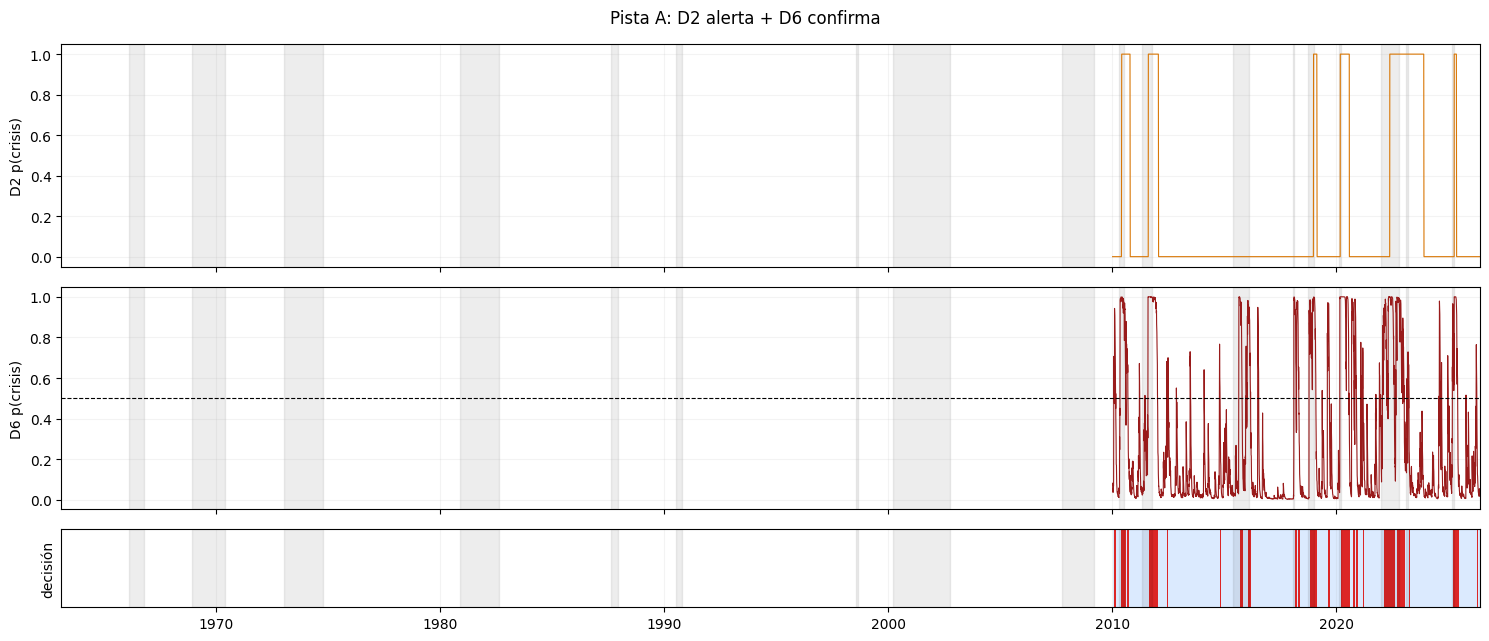

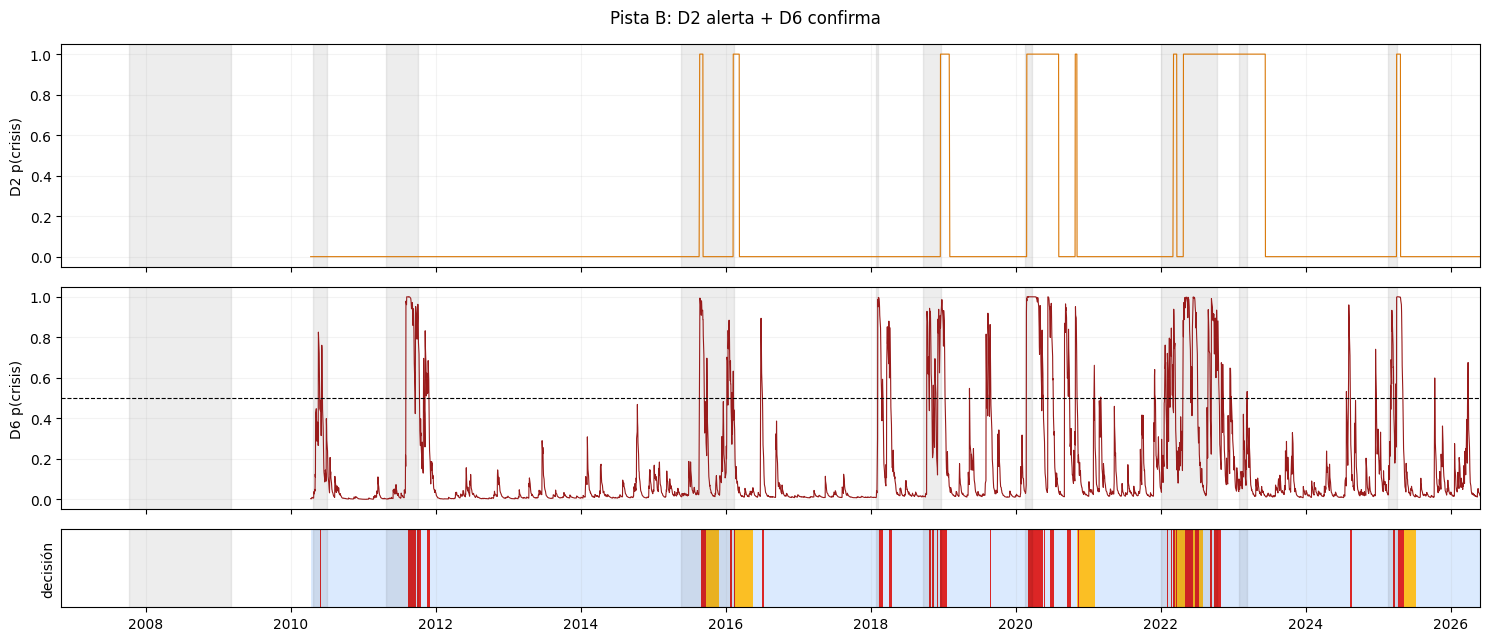

In [7]:
def plot_selected(track, frame):
    configure_evaluation(track)
    view = frame.loc[frame.index >= pd.Timestamp('2010-01-01')]
    colors = ListedColormap(['#dbeafe', '#fbbf24', '#dc2626'])
    fig, axes = plt.subplots(3, 1, figsize=(15, 6.5), sharex=True, gridspec_kw={'height_ratios': [2, 2, 0.7]})
    axes[0].plot(view.index, view['alert_probability'], color='#d97706', lw=0.8)
    axes[0].set_ylabel('D2 p(crisis)')
    axes[1].plot(view.index, view['confirmation_probability'], color='#991b1b', lw=0.8)
    axes[1].axhline(CONFIG.confirmation_threshold, color='black', ls='--', lw=0.8)
    axes[1].set_ylabel('D6 p(crisis)')
    axes[2].imshow(view['decision_code'].to_numpy()[None, :], aspect='auto', interpolation='nearest', cmap=colors, vmin=0, vmax=2, extent=[mdates.date2num(view.index[0]), mdates.date2num(view.index[-1]), 0, 1])
    axes[2].set_yticks([]); axes[2].set_ylabel('decisión'); axes[2].xaxis_date()
    for ax in axes:
        for start, end in ev.CRISIS_WINDOWS.values():
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='black', alpha=0.07)
        ax.grid(alpha=0.15)
    fig.suptitle(f'Pista {track}: D2 alerta + D6 confirma')
    fig.tight_layout(); plt.show()

for track in TRACKS:
    plot_selected(track, pair_frames[('D2+D6', track)])

## Conclusión (tras ADR-003: lags de publicación + propagación de estado + ranking por detección)

**D2+D6 sigue siendo una fusión que mejora a sus dos sensores, pero ya no es una elección clara ni aporta alerta temprana.**

1. **Como fusión funciona, pero por poco**: en ambas pistas D2+D6 mejora a D2 solo y a D6 solo (`mejora_ambos`; A: −0,071 frente a −0,104 y −0,076; B: −0,269 frente a −0,324 y −0,279). Sus días accionables caen en crisis con precisión 0,44 (A) y 0,48 (B), 2,3 y 2,8 veces la de una señal aleatoria. Pero en A **D7+D6 (−0,062) y D7 solo (−0,037) la superan**; en B D2+D6 es la mejor pareja (D7+D6 −0,279).
2. **La elección de D2 como alerta ya no es robusta**: en el cribado completo D2 (−0,170) y D7 (−0,171) están empatados. Con la propagación de estado D2 se volvió mucho más persistente: en A, 17 de sus 19 flancos llegan cuando D6 ya confirmaba, así que casi nunca actúa como aviso (2 avisos en A, 6 en B).
3. **No es alerta temprana de crisis**: los avisos se adelantan a D6 solo 2,5 sesiones de mediana en A y 2 en B, y preceden al 1,3% (A) y al 15,4% (B) de las confirmaciones. Ningún aviso anticipa el inicio de una crisis (0 frente a ≈0,1 y ≈0,7 esperados por azar); su valor es detectar *dentro* de la crisis (1 de 2 en A, 5 de 6 en B, frente a ≈0,4 y ≈1,0 por azar).
4. **El control por mitades confirma la inestabilidad**: seleccionando con la primera mitad se elegiría D12 en A y D05 en B y en la media A+B; D2 no gana en ninguna mitad. El orden entre alertas cambia entre mitades.

**Lectura para la Fase E**: con el banco corregido, la capa de alerta no añade anticipación sobre el confirmador; la fusión solo aporta una decisión algo más precisa que cada sensor aislado. La propuesta a congelar para el pseudolive debe decidirse con esto a la vista (opciones: D2+D6 por coherencia con lo ya estudiado, D7+D6 por ser mejor en A, o prescindir de la alerta y usar un único detector del ranking de detección), y el pseudolive debe usar un bloque temporal no usado en ninguna selección.

In [8]:
if SCREENING_RECOMPUTED:
    # Solo se reescriben si el cribado se recalculó entero desde paneles.
    selection.to_csv(OUTPUT / 'alert_selection.csv')
    candidate_detail.to_csv(OUTPUT / 'alert_selection_by_track.csv', index=False)
comparison.to_csv(OUTPUT / 'pair_warning_comparison.csv', index=False)
pair_scores.to_csv(OUTPUT / 'pair_event_comparison.csv', index=False)
pair_verdict.to_csv(OUTPUT / 'pair_verdict.csv', index=False)
chance_reference.to_csv(OUTPUT / 'chance_reference.csv')
ground_truth_warnings.to_csv(OUTPUT / 'warning_ground_truth.csv', index=False)
phase_vs_chance.to_csv(OUTPUT / 'warning_phase_vs_chance.csv', index=False)
episodes.to_csv(OUTPUT / 'warning_episodes.csv', index=False)
sensitivity.to_csv(OUTPUT / 'sensitivity.csv', index=False)
split_detail.to_csv(OUTPUT / 'split_half_detail.csv', index=False)
split_selection.to_csv(OUTPUT / 'split_half_selection.csv', index=False)
sorted(path.name for path in OUTPUT.glob('*.csv'))

['alert_selection.csv',
 'alert_selection_by_track.csv',
 'chance_reference.csv',
 'pair_event_comparison.csv',
 'pair_verdict.csv',
 'pair_warning_comparison.csv',
 'sensitivity.csv',
 'split_half_detail.csv',
 'split_half_selection.csv',
 'warning_episodes.csv',
 'warning_ground_truth.csv',
 'warning_phase_vs_chance.csv']